In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


# AIC encode salience

In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        # 'LexicalNoDelay',
        'LexicalDelay',
        # 'PictureNaming',
        # 'SentenceRep'
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'

# 这种方案下，我们将 ROI 直接命名为 dACC，强调其在显著性网络中的角色
dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]

dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'
HGAs.head()

100%|██████████| 320/320 [00:05<00:00, 55.86it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0023_RPIF3-4,0.249398,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,41.901912,-28.228735,17.149502
1,-1.0,D0023_R2MF2-3,0.051112,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,11.195341,-7.769187,33.884895
2,-1.0,D0023_RPSF1-2,0.095070,False,CGs,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_S_pericallosal,6.423360,-15.496811,23.453189
3,-1.0,D0023_RPIF1-2,0.231350,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,35.187262,-26.860379,15.945394
4,-1.0,D0023_RPIF2-3,0.361105,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,38.280793,-27.303607,16.525972


In [4]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0040_L1IF2-3', 'D0040_L1IF3-4', 'D0079_LFAI1-2', 'D0079_LFAI2-3', 'D0079_LFMI1-2', 'D0079_LPI9-10', 'D0103_LAI7-8', 'D0103_LAI3-4', 'D0103_LAI5-6', 'D0103_LAI6-7']


In [5]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 74880
PIC electrode count: 67200


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0023_RPIF3-4,0.249398,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,41.901912,-28.228735,17.149502
1,-1.0,D0023_R2MF2-3,0.051112,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,11.195341,-7.769187,33.884895
2,-1.0,D0023_RPSF1-2,0.095070,False,CGs,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_S_pericallosal,6.423360,-15.496811,23.453189
3,-1.0,D0023_RPIF1-2,0.231350,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,35.187262,-26.860379,15.945394
4,-1.0,D0023_RPIF2-3,0.361105,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,38.280793,-27.303607,16.525972


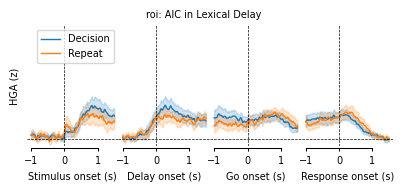

In [6]:
rois = ['AIC']
colors = [red, blue]

subset = HGAs[
    (HGAs.task == 'LexicalDelay')
    & (HGAs.roi.isin(rois))
    # & (HGAs.hemi == 'L')
    # & (HGAs.description == 'Repeat')
]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(12*cm, 4*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
line1 = sns.lineplot(
    data=subset[(subset.phase == 'stimulus')
              ],
    x='time',
    y='value',
    hue='description',
    # hue_order=rois,
    ax=ax1,
    legend=True,
    lw=1
)

line2 = sns.lineplot(
    data=subset[(subset.phase == 'delay')
              ],
    x='time',
    y='value',
    hue='description',
    # hue_order=rois,
    ax=ax2,
    legend=False,
    lw=1
)

line3 = sns.lineplot(
    data=subset[(subset.phase == 'go')
              ],
    x='time',
    y='value',
    hue='description',
    # hue_order=rois,
    ax=ax3,
    legend=False,
    lw=1
)

line4 = sns.lineplot(
    data=subset[(subset.phase == 'response')],
    x='time',
    y='value',
    hue='description',
    # hue_order=rois,
    ax=ax4,
    legend=False,
    lw=1
)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1.5)
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Delay onset (s)', fontsize=7)   
ax3.set_xlabel('Go onset (s)', fontsize=7)   
ax4.set_xlabel('Response onset (s)', fontsize=7)   
ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)
ax4.set_ylabel('', fontsize=7)

plt.suptitle('roi: ' + rois[0] + ' in Lexical Delay', fontsize=7)
# plt.savefig('../img/fig1/fig1_AIPI_temporal_PictureNaming.svg', dpi=300, bbox_inches='tight')
plt.show()

# Ave across channels: to get the significant clusters in a ROI

In [7]:
bids_root = '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/'

In [8]:
# load label array
phases = ['Stimulus', 'Delay', 'Go', 'Response']
conditions = ['Decision','Repeat']

epos = []

for phase in tqdm(phases):
    
    for sub in subset.subject.unique():
        
        picks = subset[subset.subject==sub].channel.unique().tolist()
        
        pt = BIDSPath(
            root=os.path.join(bids_root, 'derivatives', 'epoch(bipolar)'),
            subject=sub,
            datatype='epoch(band)(zscore)',
            processing=phase,
            suffix='highgamma',
            extension='.h5',
            check=False
        )

        for condition in conditions:
            epo_path = pt.update(description=condition).match()[0]
            dc_epo = mne.read_epochs(epo_path, verbose='error')
            dc_epo.pick(picks)
            data = dc_epo.get_data()            # (trial, channel, time)
            times = dc_epo.times
            # 平均 channel，保留 trial 作为观测
            mean_ch = data.mean(axis=1)         # (trial, time)
            trial_ids = [f"{sub}_trial{i}" for i in range(mean_ch.shape[0])]
            df = pd.DataFrame(mean_ch, columns=times)
            df['trial'] = trial_ids
            df = df.melt(id_vars=['trial'], var_name='time', value_name='value')
            df['condition'] = condition
            df['phase'] = phase.lower()
            df['subject'] = sub
            epos.append(df)

epos = pd.concat(epos, ignore_index=True)
epos.head()

  0%|          | 0/4 [00:00<?, ?it/s]


NameError: name 'subset' is not defined

In [9]:
from ieeg.calc.stats import time_perm_cluster

perms = []

for phase in tqdm(phases):
    # 保留 trial，先按 channel 平均得到 (trial, time)
    dec_df = epos[(epos.condition == 'Decision') & (epos.phase == phase.lower())]
    rep_df = epos[(epos.condition == 'Repeat') & (epos.phase == phase.lower())]
    # pivot to (trial x time)
    decision = dec_df.pivot(index='trial', columns='time', values='value').sort_index(axis=1)
    repeat   = rep_df.pivot(index='trial', columns='time', values='value').sort_index(axis=1)

    # 置换检验：trial 为观测，time 为维度
    mask, p = time_perm_cluster(
        decision.values,
        repeat.values,
        p_thresh=0.1,
        n_perm=2000,
        n_jobs=-1
    )
    times = decision.columns.values

    df = pd.DataFrame({
        'time': times,
        'mask': mask,
        'pval': p,
        'phase': phase.lower()
    })
    perms.append(df)
        
perms = pd.concat(perms, ignore_index=True)
perms.head()

100%|██████████| 4/4 [04:31<00:00, 67.78s/it]


,time,mask,pval,phase
0,-1.000000,False,0.503748,stimulus
1,-0.992188,False,0.304348,stimulus
2,-0.984375,False,0.184408,stimulus
3,-0.976562,False,0.169915,stimulus
4,-0.968750,False,0.238881,stimulus


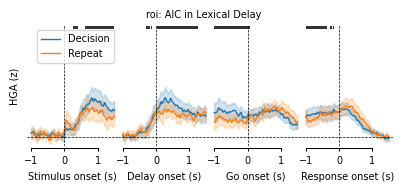

In [10]:
colors = [red, blue]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(12*cm, 4*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

for (ax, phase) in zip(fig.axes, ['stimulus', 'delay', 'go', 'response']):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True
    mask = perms.loc[perms.phase == phase, 'mask'].values
    pvals = perms.loc[perms.phase == phase, 'pval'].values
    
    line = sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='description',
        ax=ax,
        legend=legend,
        lw=1
    )
    
    # set a consistent y-range first
    ax.set_ylim(-0.1, 1.2)
    ymin, ymax = ax.get_ylim()
    pad = 0.01 * (ymax - ymin)
    bar_h = 0.02 * (ymax - ymin)

    times = perms.loc[perms.phase == phase, 'time'].values
    sig = (mask.astype(bool)) & (pvals < 0.05)

    if sig.any():
        ax.fill_between(
            times,
            ymax + pad,
            ymax + pad + bar_h,
            where=sig,
            color='k',
            alpha=0.8,
            step='mid',
            linewidth=0
        )

    ax.set_ylim(ymin, ymax + pad + bar_h + 0.01*(ymax - ymin))


for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Delay onset (s)', fontsize=7)   
ax3.set_xlabel('Go onset (s)', fontsize=7)   
ax4.set_xlabel('Response onset (s)', fontsize=7)   
ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)
ax4.set_ylabel('', fontsize=7)

plt.suptitle('roi: ' + rois[0] + ' in Lexical Delay', fontsize=7)
# plt.savefig('../img/fig1/fig1_AIPI_temporal_PictureNaming.svg', dpi=300, bbox_inches='tight')
plt.show()

# Univariate analysis: HGA difference on the repeat vs. Decsion Level

In [9]:
subset = HGAs[
    (HGAs.roi.isin(['PIC','AIC','STG','SMC','dACC',
                    'ITG','SMG','MTG','IFG','SFG',
                    'MFG','STS','AG','SPL','IPL',
                    'HG']) 
    & (HGAs.task == 'LexicalDelay'))
]
subset.head()

,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
7,-1.000000,D0023_RPIF8-9,0.532667,True,AG,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_G_pariet_inf-Angular,59.983127,-31.909288,20.181224
10,-1.000000,D0023_RPIF9-10,0.181906,True,AG,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_G_pariet_inf-Angular,63.592048,-32.361872,20.761790
19,-0.992188,D0023_RPIF8-9,0.498545,True,AG,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_G_pariet_inf-Angular,59.983127,-31.909288,20.181224
22,-0.992188,D0023_RPIF9-10,0.158769,True,AG,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_G_pariet_inf-Angular,63.592048,-32.361872,20.761790
31,-0.984375,D0023_RPIF8-9,0.455962,True,AG,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_G_pariet_inf-Angular,59.983127,-31.909288,20.181224


In [10]:
import re

# load label array
phases = ['Stimulus', 'Delay', 'Go', 'Response']
conditions = ['Decision','Repeat']

epos = []

for phase in tqdm(phases):
    
    for sub in subset.subject.unique():
        
        picks = subset[subset.subject==sub].channel.unique().tolist()
        
        pt = BIDSPath(
            root=os.path.join(bids_root, 'derivatives', 'epoch(bipolar)'),
            subject=sub,
            datatype='epoch(band)(zscore)',
            processing=phase,
            suffix='highgamma',
            extension='.h5',
            check=False
        )

        for condition in conditions:
            epo_path = pt.update(description=condition).match()[0]
            dc_epo = mne.read_epochs(epo_path, verbose='error')
            dc_epo.pick(picks)
            df = dc_epo.to_data_frame(long_format=True, verbose='error')
            # 平均 channel，保留 trial 作为观测
            # df['condition'] = df['condition'].str.extract(r'(Word|Nonword)/[^/]+')
            df['condition'] = df['condition'].str.split('/').str[2:4].str.join('/')
            df['description'] = condition
            df['phase'] = phase.lower()
            df['subject'] = sub
            epos.append(df)

epos = pd.concat(epos, ignore_index=True)
epos.head()

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [06:43<00:00, 100.99s/it]


,condition,epoch,time,channel,ch_type,value,description,phase,subject
0,Word/latin,1,-1.0,D0023_RPIF8-9,seeg,1199.448943,Decision,stimulus,D0023
1,Word/latin,1,-1.0,D0023_RPIF9-10,seeg,-129.327744,Decision,stimulus,D0023
2,Word/latin,1,-1.0,D0023_R2IF1-2,seeg,-705.475986,Decision,stimulus,D0023
3,Word/latin,1,-1.0,D0023_R2MF10-11,seeg,-53.457052,Decision,stimulus,D0023
4,Word/latin,1,-1.0,D0023_R2MF9-10,seeg,-130.285442,Decision,stimulus,D0023


In [11]:
from ieeg.calc.stats import time_perm_cluster

perms = []

for phase in tqdm(phases):
   
    des = epos[(epos.description == 'Decision') & (epos.phase == phase.lower())]
    rep = epos[(epos.description == 'Repeat') & (epos.phase == phase.lower())]
    
    decision_da = (des
        .groupby(['condition','channel','time'])['value']
        .mean() 
        .to_xarray()
    )
    repeat_da = (rep
        .groupby(['condition','channel','time'])['value']
        .mean() 
        .to_xarray()
    )

    mask, p = time_perm_cluster(
        decision_da.values,
        repeat_da.values,
        p_thresh=0.05,
        ignore_adjacency=1,
        n_perm=1000,
        n_jobs=10
    )

    times = repeat_da.time.values
    channels = repeat_da.channel.values

    df = pd.DataFrame({
        'channel': np.repeat(channels, len(times)),
        'time': np.tile(times, len(channels)),
        'mask': mask.ravel(),
        'p': p.ravel(),
        'phase': phase.lower()
    })
    perms.append(df)
        
perms = pd.concat(perms, ignore_index=True)
perms.head()

  0%|          | 0/4 [00:00<?, ?it/s][Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=10)]: Done   2 tasks      | elapsed:    0.9s
[Parallel(n_jobs=10)]: Done   3 tasks      | elapsed:    1.0s
[Parallel(n_jobs=10)]: Done   4 tasks      | elapsed:    1.2s
[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:    1.2s
[Parallel(n_jobs=10)]: Done   6 tasks      | elapsed:    1.3s
[Parallel(n_jobs=10)]: Done   7 tasks      | elapsed:    1.3s
[Parallel(n_jobs=10)]: Done   8 tasks      | elapsed:    1.3s
[Parallel(n_jobs=10)]: Done   9 tasks      | elapsed:    1.3s
[Parallel(n_jobs=10)]: Done  10 tasks      | elapsed:    1.3s
[Parallel(n_jobs=10)]: Done  11 tasks      | elapsed:    1.6s
[Parallel(n_jobs=10)]: Done  12 tasks      | elapsed:    1.7s
[Parallel(n_jobs=10)]: Done  13 tasks      | elapsed:    1.8s
[Parallel(n_jobs=10)]: Done  14 tasks      | elapsed:    2.0s
[Parallel(n_j

,channel,time,mask,p,phase
0,D0023_R1MF1-2,-1.000000,0,0.593407,stimulus
1,D0023_R1MF1-2,-0.992188,0,0.658342,stimulus
2,D0023_R1MF1-2,-0.984375,0,0.754246,stimulus
3,D0023_R1MF1-2,-0.976562,0,0.815185,stimulus
4,D0023_R1MF1-2,-0.968750,0,0.830170,stimulus


In [12]:
agg = epos.groupby(['phase','description','channel','time'], as_index=False)['value'].mean()

use_mask = (
    (agg['phase'].isin(['stimulus', 'delay']) & (agg['time'] > 0))
    | (agg['phase'].isin(['go', 'response']) & (agg['time'] < 0))
)

phase_mean = (
    agg.loc[use_mask]
    .groupby(['phase', 'description', 'channel'], as_index=False)['value']
    .mean()
)

delta = (
    phase_mean.pivot_table(index=['phase', 'channel'], columns='description', values='value')
    .pipe(lambda x: (x['Decision'] - x['Repeat']))
    .reset_index(name='delta')
)

subset = HGAs[HGAs.channel.isin(epos.channel)][['channel', 'hemi', 'roi', 'label','x','y','z']]
subset.drop_duplicates(subset=['channel'], keep='first', inplace=True)
delta = delta.merge(subset, on='channel', how='left')
delta.head()

,phase,channel,delta,hemi,roi,label,x,y,z
0,delay,D0023_R1MF1-2,-63.800292,R,dACC,ctx_rh_G_and_S_cingul-Mid-Ant,9.295536,5.962643,32.639046
1,delay,D0023_R1MF14-15,52.980806,R,SMC,ctx_rh_G_precentral,56.249805,1.672702,35.132438
2,delay,D0023_R2IF1-2,-45.505952,R,PIC,ctx_rh_S_circular_insula_sup,33.089530,-8.192050,18.614382
3,delay,D0023_R2IF2-3,14.244535,R,PIC,ctx_rh_S_circular_insula_sup,36.686262,-8.172090,19.151989
4,delay,D0023_R2MF1-2,15.968361,R,dACC,ctx_rh_G_and_S_cingul-Mid-Ant,7.071022,-7.307247,33.304338


In [16]:
# 创建简化的显著channel表
perm_ = perms[
    (perms['mask'] == 1) & (perms.p < 0.01)
][['phase', 'channel']].drop_duplicates()

significant_delta = delta.merge(
    perm_, 
    on=['phase', 'channel'], 
    how='inner' 
)
significant_delta.head()

,phase,channel,delta,hemi,roi,label,x,y,z
0,delay,D0027_LAI2-3,52.680462,L,AIC,ctx_lh_S_circular_insula_sup,-32.470676,9.175895,4.597974
1,delay,D0027_LAI9-10,233.902466,L,SFG,ctx_lh_G_front_sup,-19.576652,37.500153,53.456482
2,delay,D0027_LMSF3-4,274.920684,L,dACC,ctx_lh_G_and_S_cingul-Mid-Ant,-8.796469,11.611534,47.435991
3,delay,D0027_LMSF6-7,124.249693,L,SFG,ctx_lh_G_front_sup,-13.450834,10.801618,63.773861
4,delay,D0027_LMSF7-8,260.434059,L,SFG,ctx_lh_G_front_sup,-15.038298,10.423931,68.909268


Reading labels from parcellation...


   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-18 17:39:54.482 (2480.678s) [    7FB63AC9B440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x5a627740): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-18 17:39:54.570 (2480.765s) [    7FB63AC9B440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x5a627740): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

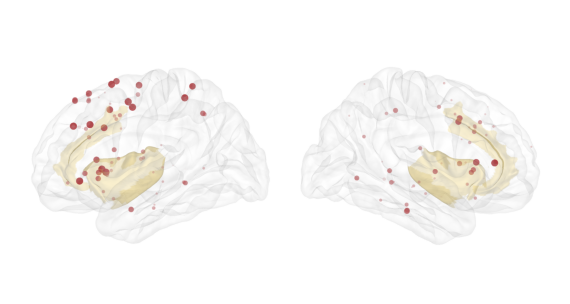

In [17]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree

labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',
    hemi='both', subjects_dir=recon_dir
)

lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)

# 使用显著数据进行可视化
cord = significant_delta[(significant_delta.phase=='delay')][['x', 'y', 'z']].values
mean_delta = significant_delta[(significant_delta.phase=='delay')]['delta'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# Color + size mapping
cmap = reds
max_abs = np.percentile(np.abs(mean_delta), 95)
max_abs = max(max_abs, 1e-6)
norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)

size_min, size_max = 1, 35
alpha_min, alpha_max = 0.2, 0.9

def val_to_size(v, vmax_abs, size_min, size_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return size_min + x * (size_max - size_min)

def val_to_alpha(v, vmax_abs, alpha_min, alpha_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return alpha_min + x * (alpha_max - alpha_min)

lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)

if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_vals = mean_delta[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_projected_coords = lh_coords_pial[lh_indices]

    valid_mask = np.zeros(len(lh_cord), dtype=bool)
    for i, idx in enumerate(lh_indices):
        for lab in labels:
            if lab.hemi == 'lh' and idx in lab.vertices:
                valid_mask[i] = True
                break

    if valid_mask.any():
        coords_valid = lh_projected_coords[valid_mask]
        vals_valid = lh_vals[valid_mask]
        for pt, v in zip(coords_valid, vals_valid):
            cloud = pv.PolyData(pt.reshape(1, 3))
            color = cmap(norm(v))[:3]
            size = val_to_size(v, max_abs, size_min, size_max)
            alpha = val_to_alpha(v, max_abs, alpha_min, alpha_max)
            lh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=float(size),
                color=color,
                lighting=False,
                smooth_shading=False,
                opacity=float(alpha),
            )

if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_vals = mean_delta[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_projected_coords = rh_coords_pial[rh_indices]

    valid_mask = np.zeros(len(rh_cord), dtype=bool)
    for i, idx in enumerate(rh_indices):
        for lab in labels:
            if lab.hemi == 'rh' and idx in lab.vertices:
                valid_mask[i] = True
                break

    if valid_mask.any():
        coords_valid = rh_projected_coords[valid_mask]
        vals_valid = rh_vals[valid_mask]
        for pt, v in zip(coords_valid, vals_valid):
            cloud = pv.PolyData(pt.reshape(1, 3))
            color = cmap(norm(v))[:3]
            size = val_to_size(v, max_abs, size_min, size_max)
            alpha = val_to_alpha(v, max_abs, alpha_min, alpha_max)
            rh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=float(size),
                color=color,
                lighting=False,
                smooth_shading=False,
                opacity=float(alpha),
            )

insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)

acc_patterns = ['G_and_S_cingul-Mid-Ant','G_and_S_cingul-Mid-Ant',
                'G_and_S_cingul-Ant', 'G_and_S_cingul-Ant']

for lab in labels:
    if any(pattern in lab.name for pattern in acc_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)


for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]})
plt.subplots_adjust(wspace=-0.5)
ax1.imshow(lh_brain.screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(rh_brain.screenshot(mode="rgb"))
ax2.axis("off")

lh_brain.close()
rh_brain.close()

plt.tight_layout()
plt.show()